In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

In [5]:
df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,8.0,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,8.0,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,4.0,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,9.0,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,1.0,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0


First 5 Rows
    order_id  order_date customer_id customer_name   age gender   region  \
0  ORD-03903  2024-08-15   CUST32603   Aarav Mehta  39.0  Other  Central   
1  ORD-02198  2022-08-16   CUST07881  Sanjay Verma  28.0   Male     West   
2  ORD-01348  2021-08-29   CUST49296  Pooja Sharma  41.0  Other     West   
3  ORD-02076  2022-07-05   CUST05587   Priya Reddy  29.0  Other     West   
4  ORD-00287  2020-05-07   CUST58035   Ritu Sharma   9.0   Male  Central   

        city product_category product_name  quantity  unit_price  \
0     Raipur        Groceries        Sugar       8.0      346.32   
1     Mumbai           Beauty    Sunscreen       8.0      858.66   
2      Surat        Furniture         Sofa       4.0    25941.32   
3  Ahmedabad        Furniture    Bed Frame       9.0    22071.92   
4     Nagpur        Groceries  Cooking Oil       1.0      320.06   

   discount_pct  sales_amount    profit  shipping_cost payment_method  \
0           NaN       4043.14    289.18         

/tmp/ipykernel_663/596150171.py:44: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["order_date"] = pd.to_datetime(
/tmp/ipykernel_663/596150171.py:60: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_663/596150171.py:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will

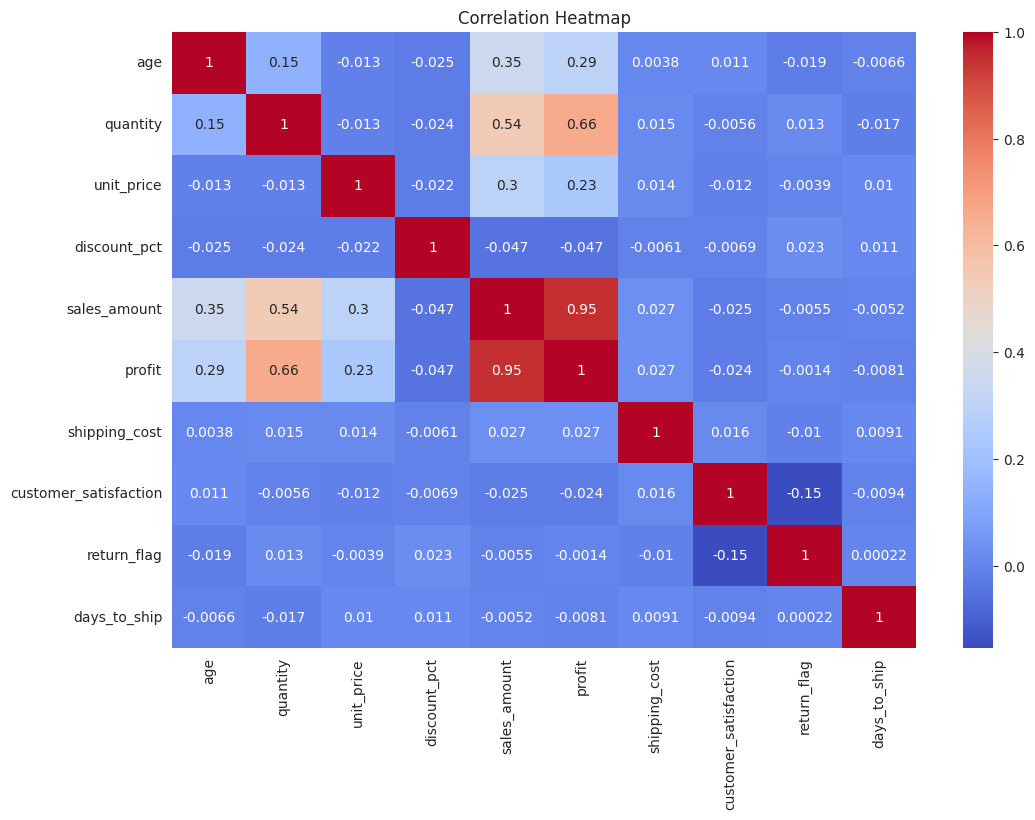

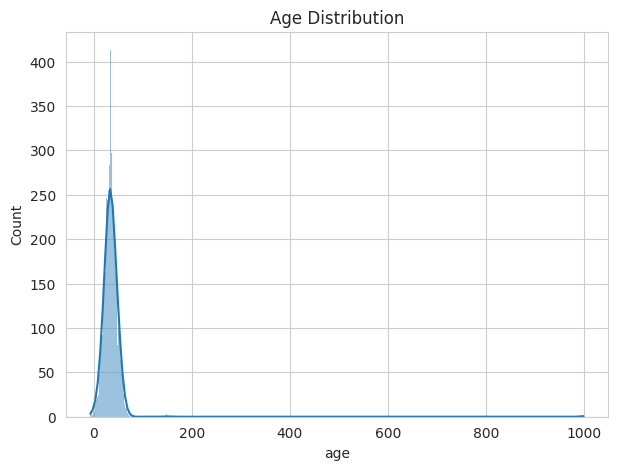

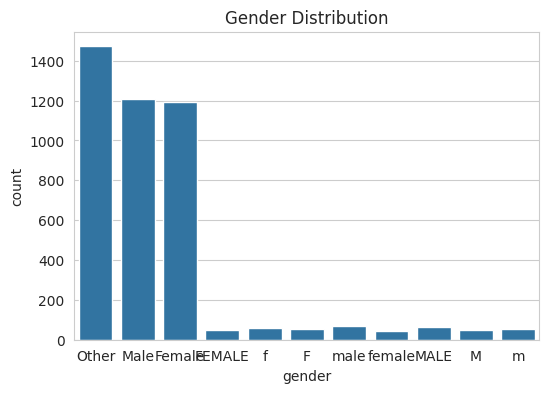

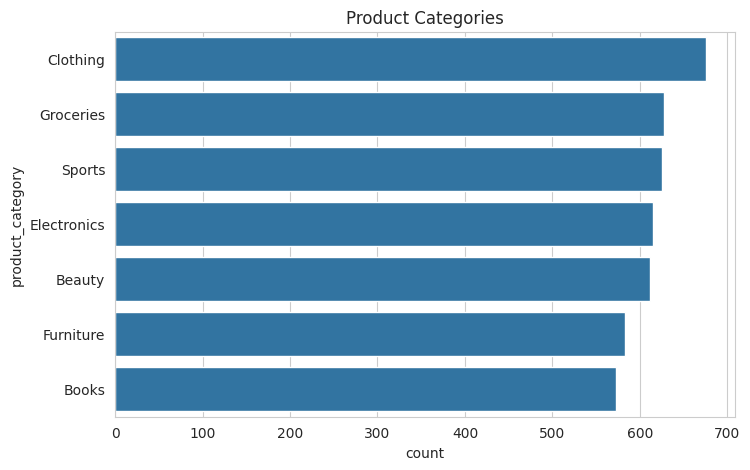

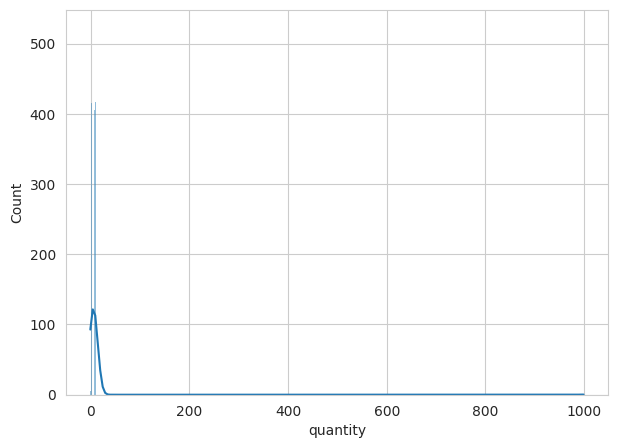

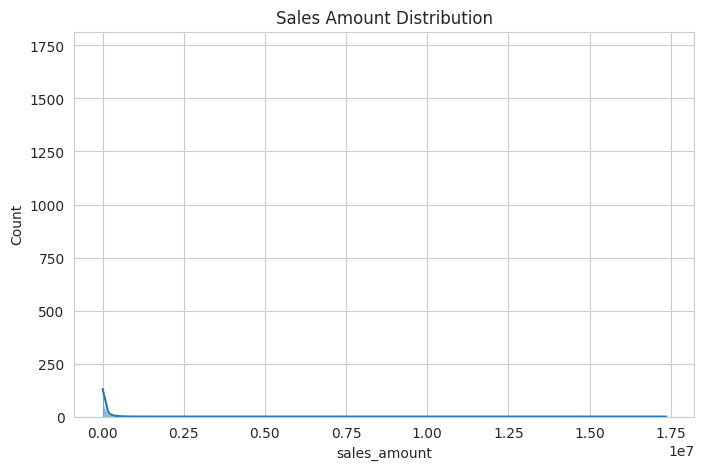

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Basic Information
# -----------------------------

print("First 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

print("\nShape")
print(df.shape)

print("\nInfo")
df.info()

print("\nData Types")
print(df.dtypes)

print("\nSummary Statistics")
print(df.describe())

print("\nCategorical Summary")
print(df.describe(include='object'))

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nUnique Values")
print(df.nunique())

# -----------------------------
# Date Conversion
# -----------------------------

df["order_date"] = pd.to_datetime(
    df["order_date"],
    dayfirst=True,
    errors="coerce"
)

print("\nNull values after date conversion")
print(df["order_date"].isnull().sum())

# -----------------------------
# Fill Missing Values
# -----------------------------

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# -----------------------------
# Correlation
# -----------------------------

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# -----------------------------
# Age Distribution
# -----------------------------

plt.figure(figsize=(7,5))

sns.histplot(df["age"], kde=True)

plt.title("Age Distribution")

plt.show()

# -----------------------------
# Gender Distribution
# -----------------------------

plt.figure(figsize=(6,4))

sns.countplot(data=df,x="gender")

plt.title("Gender Distribution")

plt.show()

# -----------------------------
# Product Category
# -----------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y="product_category",
    order=df["product_category"].value_counts().index
)

plt.title("Product Categories")

plt.show()

# -----------------------------
# Quantity Distribution
# -----------------------------

plt.figure(figsize=(7,5))

sns.histplot(df["quantity"],kde=True)

plt.show()

# -----------------------------
# Sales Amount
# -----------------------------

plt.figure(figsize=(8,5))

sns.histplot(df["sales_amount"],kde=True)

plt.title("Sales Amount Distribution")

plt.show()

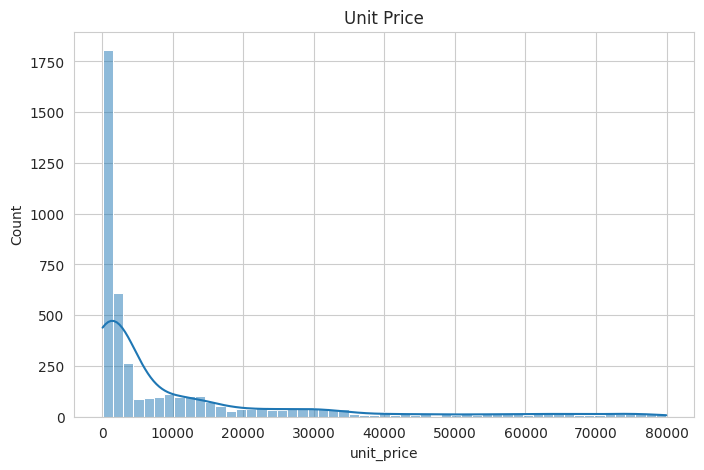

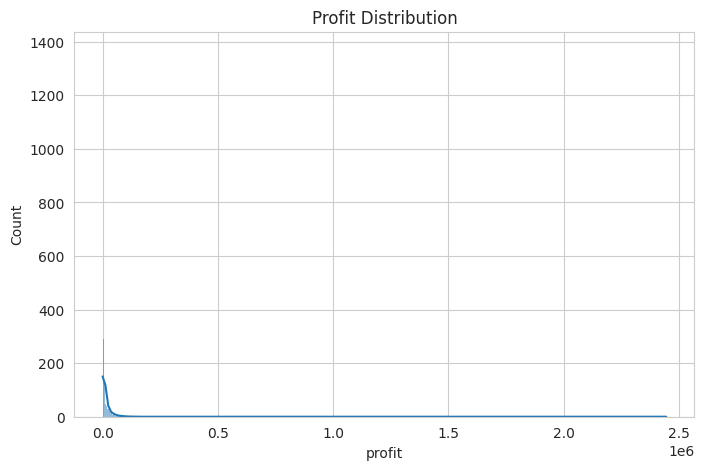

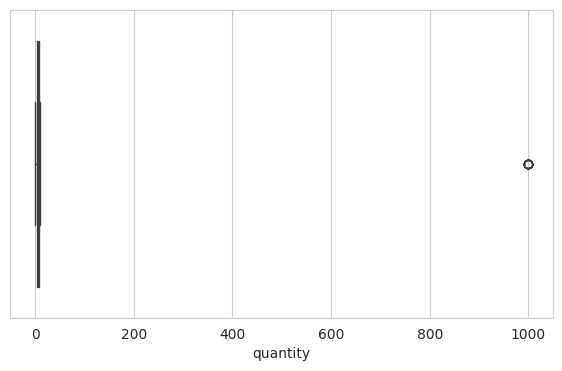

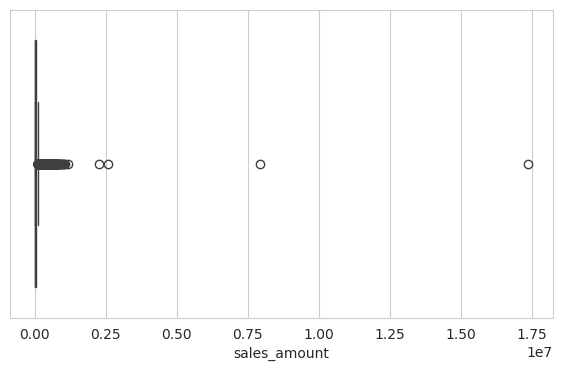

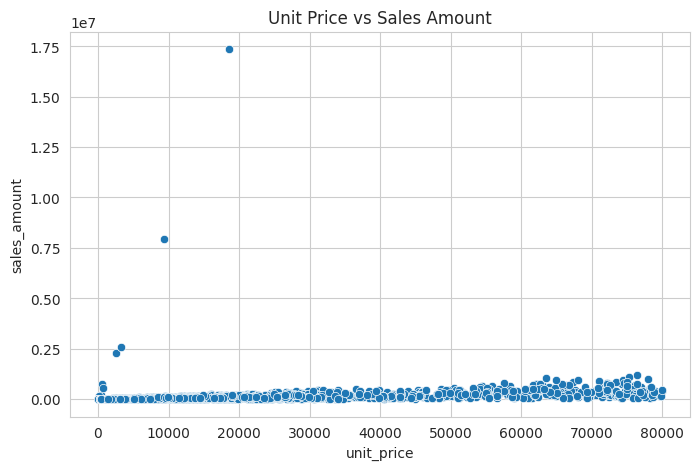

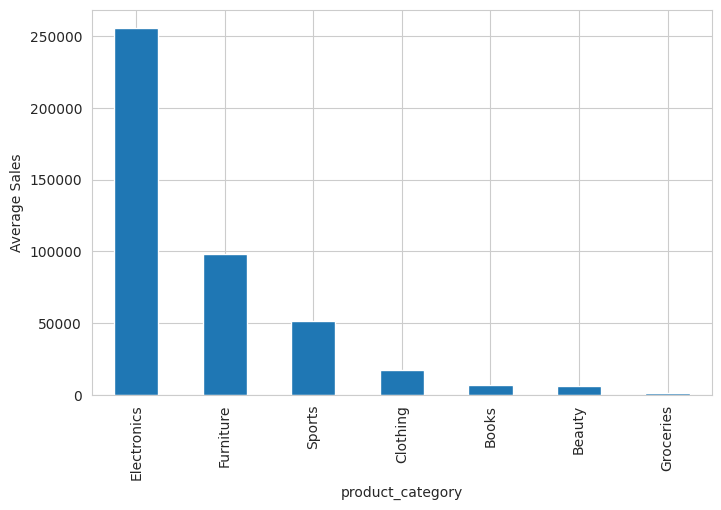

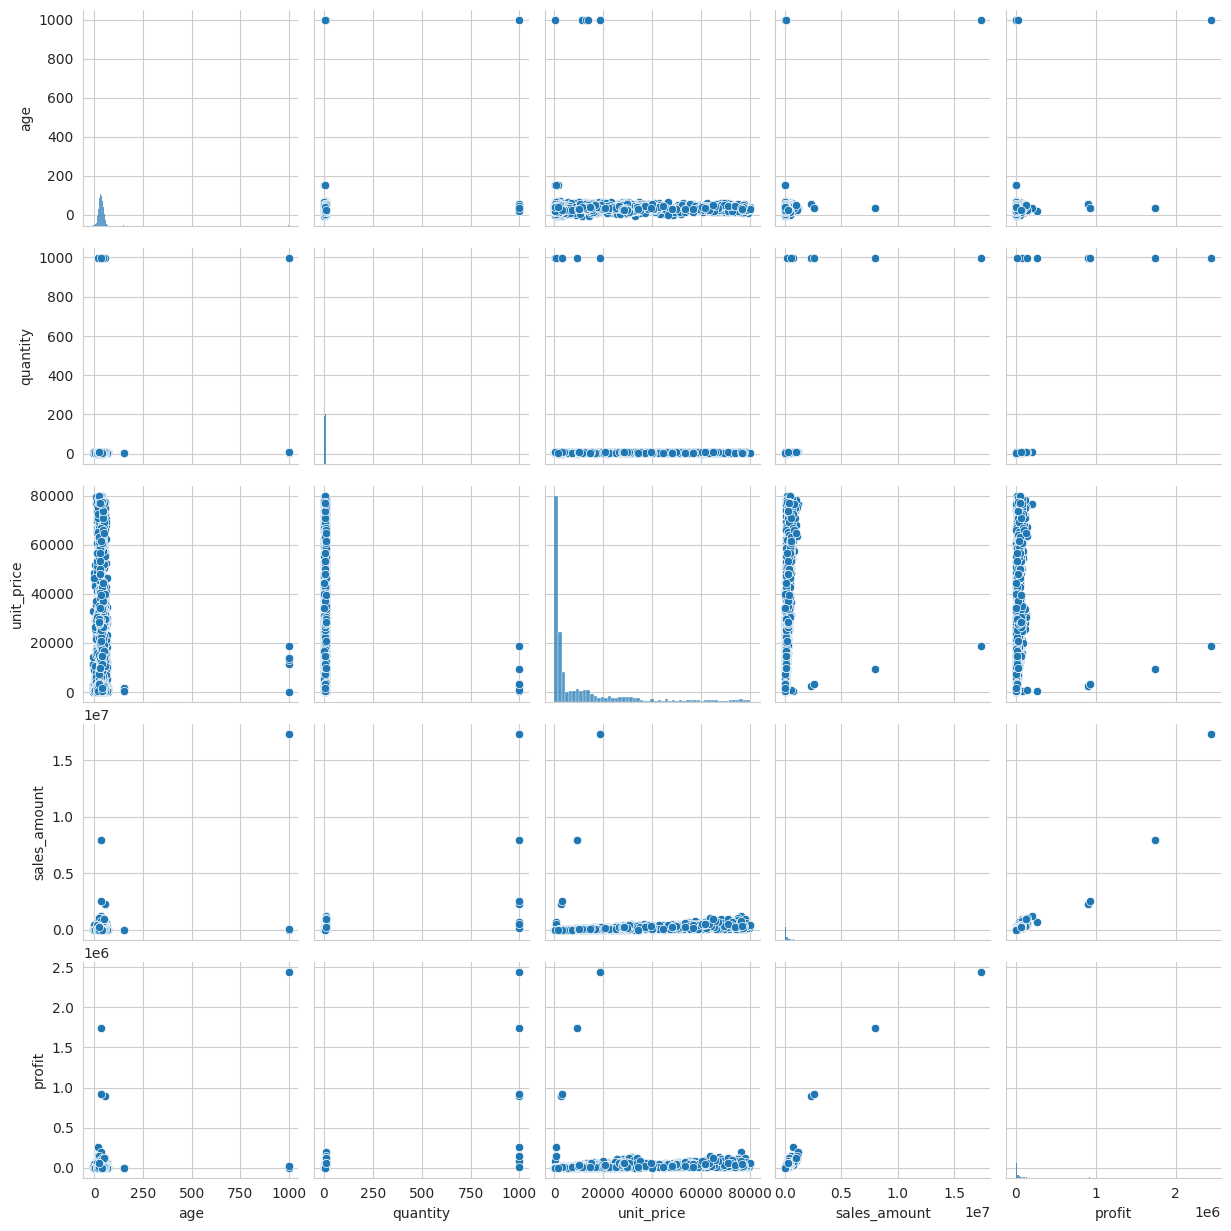

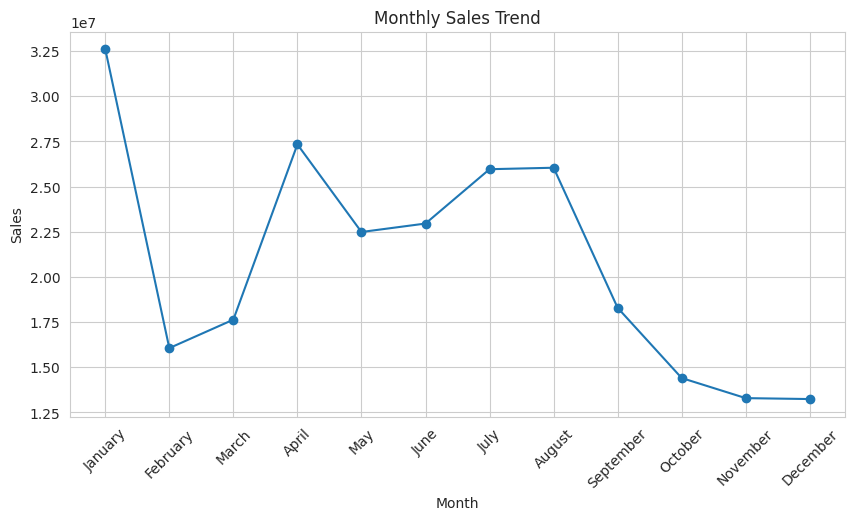

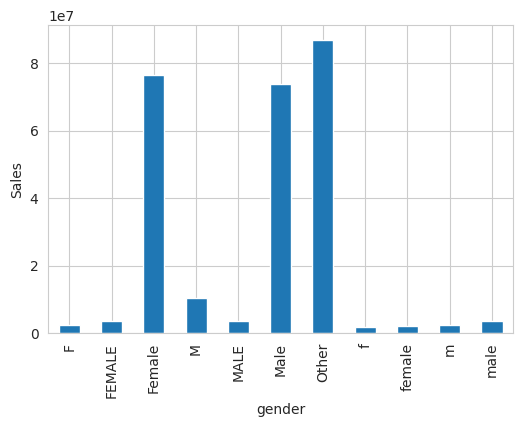

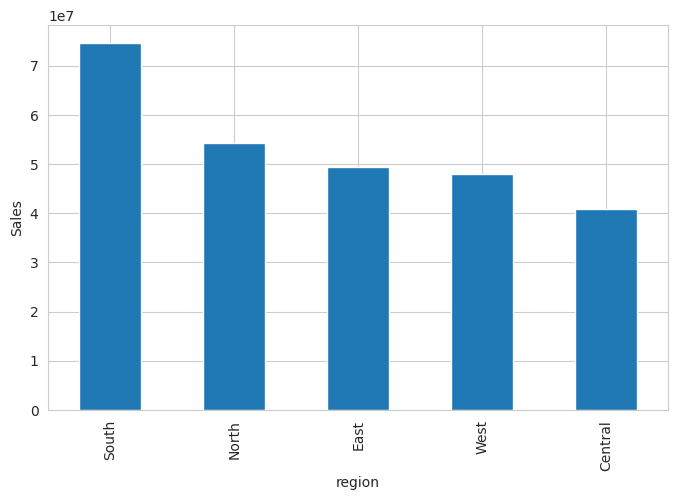

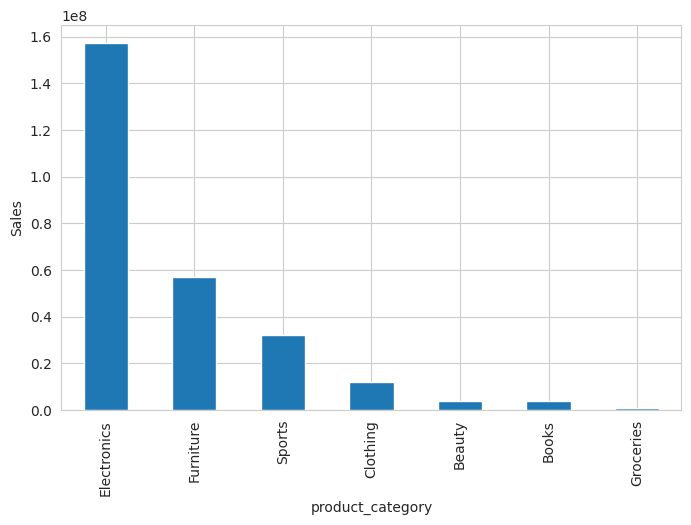

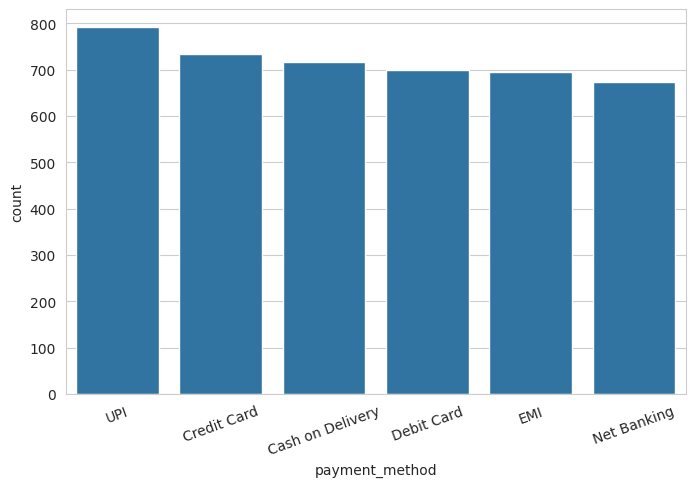

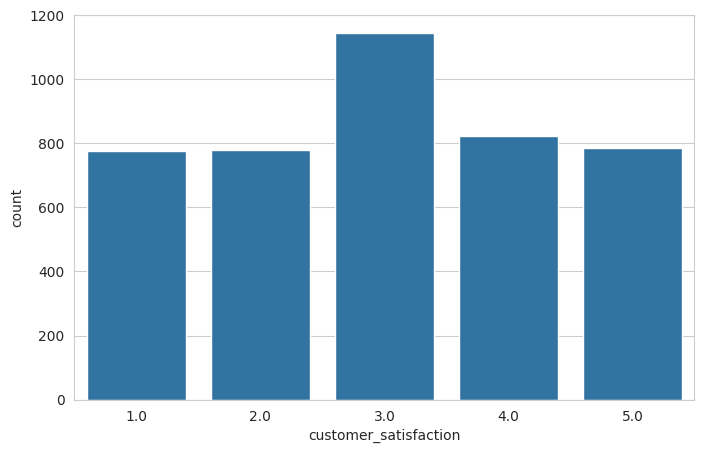

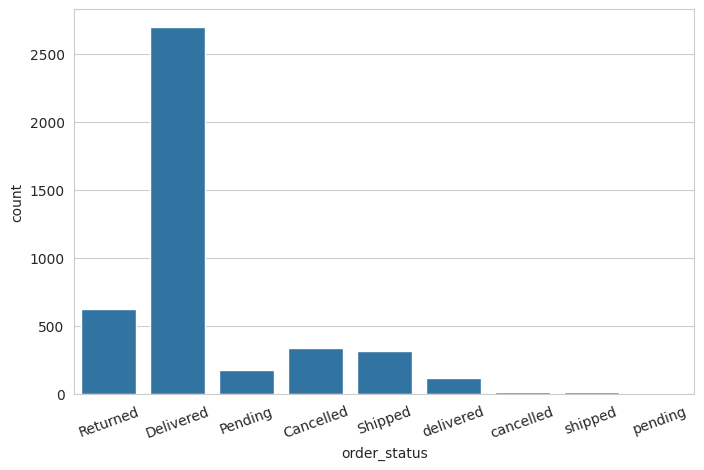

In [9]:
# -----------------------------
# Unit Price
# -----------------------------

plt.figure(figsize=(8,5))

sns.histplot(df["unit_price"],kde=True)

plt.title("Unit Price")

plt.show()

# -----------------------------
# Profit
# -----------------------------

plt.figure(figsize=(8,5))

sns.histplot(df["profit"],kde=True)

plt.title("Profit Distribution")

plt.show()

# -----------------------------
# Quantity Boxplot
# -----------------------------

plt.figure(figsize=(7,4))

sns.boxplot(x=df["quantity"])

plt.show()

# -----------------------------
# Sales Boxplot
# -----------------------------

plt.figure(figsize=(7,4))

sns.boxplot(x=df["sales_amount"])

plt.show()

# -----------------------------
# Scatter Plot
# -----------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="unit_price",
    y="sales_amount"
)

plt.title("Unit Price vs Sales Amount")

plt.show()

# -----------------------------
# Average Sales by Category
# -----------------------------

plt.figure(figsize=(8,5))

df.groupby("product_category")["sales_amount"]\
.mean()\
.sort_values(ascending=False)\
.plot(kind="bar")

plt.ylabel("Average Sales")

plt.show()

# -----------------------------
# Pair Plot
# -----------------------------

sns.pairplot(
    df[
        [
            "age",
            "quantity",
            "unit_price",
            "sales_amount",
            "profit"
        ]
    ]
)

plt.show()

# -----------------------------
# Monthly Sales Trend
# -----------------------------

df["Month"] = df["order_date"].dt.month_name()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = df.groupby("Month")["sales_amount"].sum()

monthly = monthly.reindex(month_order)

plt.figure(figsize=(10,5))

plt.plot(monthly.index,monthly.values,marker='o')

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

# -----------------------------
# Sales by Gender
# -----------------------------

plt.figure(figsize=(6,4))

df.groupby("gender")["sales_amount"]\
.sum()\
.plot(kind="bar")

plt.ylabel("Sales")

plt.show()

# -----------------------------
# Sales by Region
# -----------------------------

plt.figure(figsize=(8,5))

df.groupby("region")["sales_amount"]\
.sum()\
.sort_values(ascending=False)\
.plot(kind="bar")

plt.ylabel("Sales")

plt.show()

# -----------------------------
# Sales by Product Category
# -----------------------------

plt.figure(figsize=(8,5))

df.groupby("product_category")["sales_amount"]\
.sum()\
.sort_values(ascending=False)\
.plot(kind="bar")

plt.ylabel("Sales")

plt.show()

# -----------------------------
# Payment Method
# -----------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="payment_method",
    order=df["payment_method"].value_counts().index
)

plt.xticks(rotation=20)

plt.show()

# -----------------------------
# Customer Satisfaction
# -----------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="customer_satisfaction"
)

plt.show()

# -----------------------------
# Order Status
# -----------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="order_status"
)

plt.xticks(rotation=20)

plt.show()